# 개인 유튜브 채널 숏폼 vs 롱폼 참여율 비교 분석
### 목적: 개인 유튜브 콘텐츠에서 숏폼의 참여율이 롱폼보다 높음을 증명

## 1. 환경 설정

In [2]:
import os
import re
import pandas as pd
from dotenv import load_dotenv
from googleapiclient.discovery import build
from sqlalchemy import create_engine, text
import pymysql
import plotly.graph_objects as go

load_dotenv()

api_key    = os.getenv('YOUTUBE_API_KEY')
mysql_host = os.getenv('MYSQL_HOST', 'localhost')
mysql_user = os.getenv('MYSQL_USER', 'root')
mysql_pw   = os.getenv('MYSQL_PASSWORD', '')
mysql_db   = os.getenv('MYSQL_DB', 'youtube_data')

youtube = build('youtube', 'v3', developerKey=api_key)
engine  = create_engine(f'mysql+pymysql://{mysql_user}:{mysql_pw}@{mysql_host}/{mysql_db}?charset=utf8mb4')

print(f'API KEY : {api_key[:8]}...')
print('연결 완료')

API KEY : AIzaSyCu...
연결 완료


## 2. 공통 함수

In [3]:
def parse_duration(iso_duration):
    """ISO 8601 형식을 초 단위로 변환한다."""
    if not iso_duration:
        return 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', iso_duration)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s

def classify_format(duration_seconds, title):
    """60초 이하 또는 #shorts 태그 = shortform, 나머지 = longform"""
    if duration_seconds <= 60 or '#shorts' in title.lower() or '#short' in title.lower():
        return 'shortform'
    return 'longform'

## 3. 채널 검색

In [4]:
def search_channel(query):
    """채널명으로 채널 ID를 검색한다."""
    res = youtube.search().list(
        part='snippet',
        q=query,
        type='channel',
        maxResults=5
    ).execute()
    
    channels = []
    for item in res.get('items', []):
        channels.append({
            'channel_id': item['snippet']['channelId'],
            'title':      item['snippet']['title']
        })
    return channels

# 채널 목록 검색
channel_queries2 = ['빠더너스', '숏박스', '핫이슈지']

for query in channel_queries2:
    results = search_channel(query)
    print(f'\n[{query}]')
    for i, ch in enumerate(results):
        print(f'  [{i}] {ch["title"]} | {ch["channel_id"]}')


[빠더너스]
  [0] 빠더너스 BDNS | UC5xLohcPE65Y-U62X6snmRQ
  [1] 빠더너스 REAL 팬 계정 | UCez3f8o9FrJh6EHeFaIgPow
  [2] 빠더너스 사생팬 | UCC7KpBfIPYBqXzeiV8YUAbQ
  [3] 빠더너스 | UCFuQsaoRHEt_cNHbDBHS8pQ
  [4] 수쩡민 | UCZB8FKm68UQPGWKebOel4Pw

[숏박스]
  [0] 숏박스 | UC1B6SalAoiJD7eHfMUA9QrA
  [1] 우낌표 | UCvpvxehqmA95v9Q5RS6B_DQ
  [2] 킥서비스 | UC1x03ziDHPct2xTikLyfMDA
  [3] 너덜트 | UCXEKwWflysXu312NmIP_dlw
  [4] 숏박스(box) | UCXQ6LhAxedTlXT_AUrPduhQ

[핫이슈지]
  [0] 핫이슈지 | UCdMeT09aEFDCH0NghWV41HQ
  [1] 핫이슈지 | UC-I5hy6FQmngNDpHDaAoiwQ
  [2] 뻔뻔쇼츠 | UCMiU-Jfnocgx-tr0SIuVeTg
  [3] 핫이슈 | UC1RezYqr880nnRR939x9cqg
  [4] 핫이슈 | UChu5iNRNbbtXbjiNFLjn6Rw


## 4. 채널 ID 확정

In [5]:
# 위 결과에서 올바른 채널 ID 입력
CHANNELS = {
    '빠더너스': 'UC5xLohcPE65Y-U62X6snmRQ',  # [0] 빠더너스 BDNS
    '숏박스':   'UC1B6SalAoiJD7eHfMUA9QrA',  # [0] 숏박스
    '핫이슈지': 'UCdMeT09aEFDCH0NghWV41HQ',  # [0] 핫이슈지
}
print('채널 확정 완료')

채널 확정 완료


## 5. 영상수집

In [6]:
def get_channel_videos(channel_id, channel_name, max_results=50):
    """채널의 최근 영상을 수집한다."""
    # 업로드 플레이리스트 ID 가져오기
    res = youtube.channels().list(
        part='contentDetails',
        id=channel_id
    ).execute()
    playlist_id = res['items'][0]['contentDetails']['relatedPlaylists']['uploads']
    
    # 영상 ID 수집
    video_ids = []
    next_token = None
    while len(video_ids) < max_results:
        res = youtube.playlistItems().list(
            part='contentDetails',
            playlistId=playlist_id,
            maxResults=50,
            pageToken=next_token
        ).execute()
        for item in res.get('items', []):
            video_ids.append(item['contentDetails']['videoId'])
        next_token = res.get('nextPageToken')
        if not next_token:
            break

    video_ids = video_ids[:max_results]

    # 영상 상세 정보 수집
    video_list = []
    for i in range(0, len(video_ids), 50):
        chunk = video_ids[i:i+50]
        res = youtube.videos().list(
            part='snippet,statistics,contentDetails',
            id=','.join(chunk)
        ).execute()
        for item in res.get('items', []):
            title        = item['snippet']['title']
            duration_sec = parse_duration(item['contentDetails']['duration'])
            stats        = item['statistics']
            view         = int(stats.get('viewCount', 1))
            like         = int(stats.get('likeCount', 0))
            comment      = int(stats.get('commentCount', 0))
            video_list.append({
                'channel_name':    channel_name,
                'video_id':        item['id'],
                'title':           title,
                'duration_seconds': duration_sec,
                'format_type':     classify_format(duration_sec, title),
                'view_count':      view,
                'like_count':      like,
                'comment_count':   comment,
                'like_rate':       round(like / view * 100, 4),
                'comment_rate':    round(comment / view * 100, 4),
            })
    print(f'{channel_name}: {len(video_list)}개 수집')
    return video_list

# 전체 채널 수집
all_videos = []
for channel_name, channel_id in CHANNELS.items():
    videos = get_channel_videos(channel_id, channel_name)
    all_videos.extend(videos)

print(f'\n총 수집: {len(all_videos)}개')

빠더너스: 50개 수집
숏박스: 50개 수집
핫이슈지: 50개 수집

총 수집: 150개


## 6. DataFrame 정리

In [7]:
df = pd.DataFrame(all_videos)

num_cols = ['duration_seconds', 'view_count', 'like_count', 'comment_count', 'like_rate', 'comment_rate']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

str_cols = ['channel_name', 'video_id', 'title', 'format_type']
for col in str_cols:
    df[col] = df[col].fillna('')

print('포맷 분포:')
print(df['format_type'].value_counts())
df.head(3)

포맷 분포:
format_type
shortform    93
longform     57
Name: count, dtype: int64


,channel_name,video_id,title,duration_seconds,format_type,view_count,like_count,comment_count,like_rate,comment_rate
0,빠더너스,ET_aHj-hxcw,안 해봤다고?,27,shortform,5251,16,1,0.3047,0.0190
1,빠더너스,EPhi9C6NZRY,다들 무슨 이모티콘 써?,31,shortform,4318,16,1,0.3705,0.0232
2,빠더너스,nu_F1xVxJwE,엄태구와 오지 않는 까눌레를 기다리며,1644,longform,11315,561,77,4.9580,0.6805


## 7. MySQL 저장

In [8]:
df.to_sql(
    name='variety_engagement',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=500
)
print('저장 완료')

저장 완료


## 8. 시각화

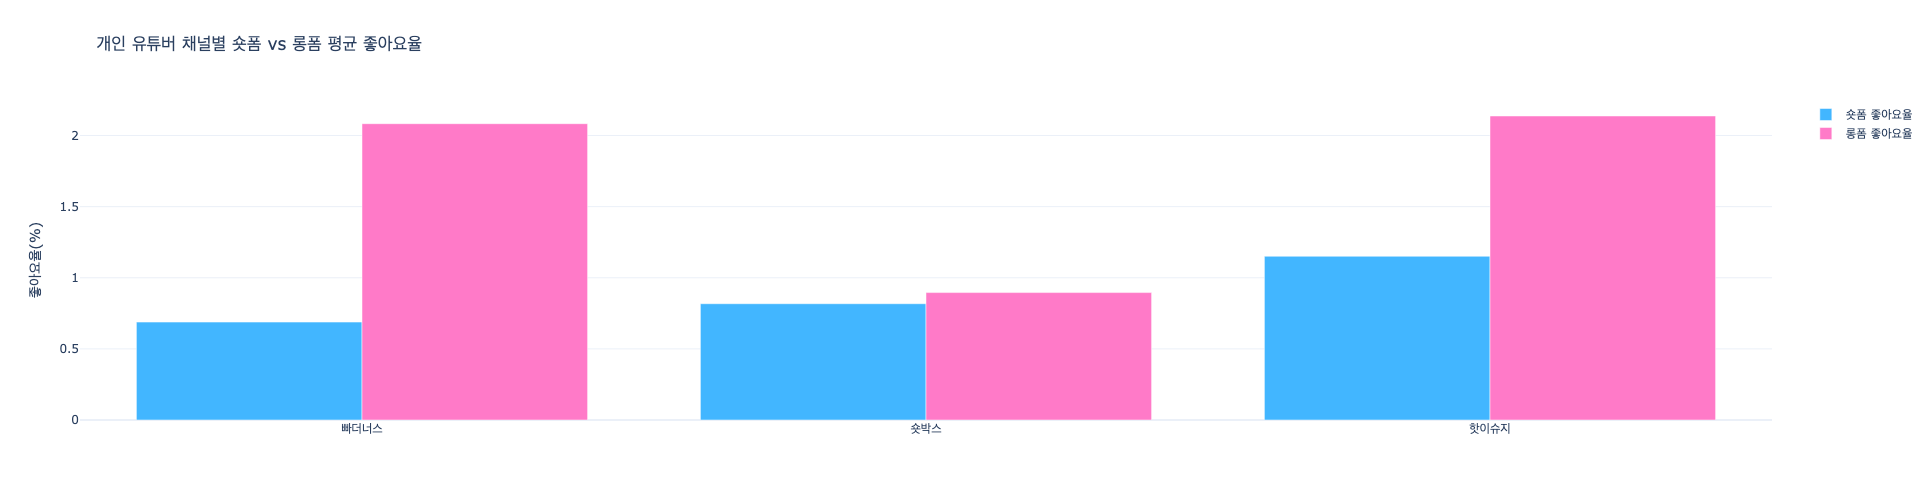

In [10]:
# 채널별 숏폼/롱폼 참여율 비교
summary = df.groupby(['channel_name', 'format_type'])[['like_rate', 'comment_rate']].mean().reset_index()

shortform_df = summary[summary['format_type'] == 'shortform']
longform_df  = summary[summary['format_type'] == 'longform']

channels = list(CHANNELS.keys())

fig = go.Figure()
fig.add_trace(go.Bar(
    name='숏폼 좋아요율',
    x=channels,
    y=shortform_df.set_index('channel_name').reindex(channels)['like_rate'],
    marker_color='#42B6FF'
))
fig.add_trace(go.Bar(
    name='롱폼 좋아요율',
    x=channels,
    y=longform_df.set_index('channel_name').reindex(channels)['like_rate'],
    marker_color='#FF7AC8'
))
fig.update_layout(
    title='개인 유튜버 채널별 숏폼 vs 롱폼 평균 좋아요율',
    yaxis_title='좋아요율(%)',
    barmode='group',
    template='plotly_white',
    height=500
)
fig.show()

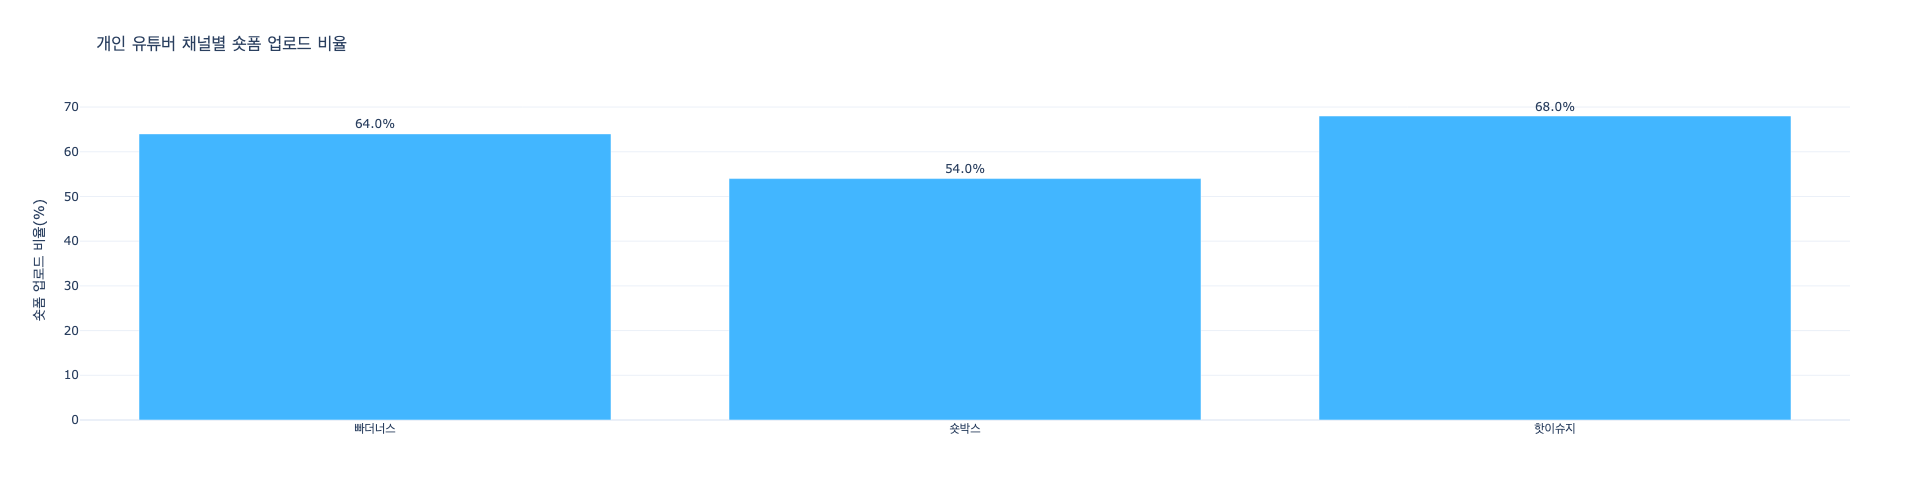

In [12]:
# 채널별 숏폼 업로드 비율
upload_ratio = df.groupby(['channel_name', 'format_type']).size().reset_index(name='count')
upload_ratio['total'] = upload_ratio.groupby('channel_name')['count'].transform('sum')
upload_ratio['ratio'] = round(upload_ratio['count'] / upload_ratio['total'] * 100, 1)

shortform_ratio = upload_ratio[upload_ratio['format_type'] == 'shortform'].set_index('channel_name')['ratio']
channels = list(CHANNELS.keys())

fig = go.Figure(go.Bar(
    x=channels,
    y=shortform_ratio.reindex(channels).fillna(0),
    text=[f"{shortform_ratio.reindex(channels).fillna(0)[ch]}%" for ch in channels],
    textposition='outside',
    marker_color='#42B6FF'
))
fig.update_layout(
    title='개인 유튜버 채널별 숏폼 업로드 비율',
    yaxis_title='숏폼 업로드 비율(%)',
    template='plotly_white',
    height=500
)
fig.show()

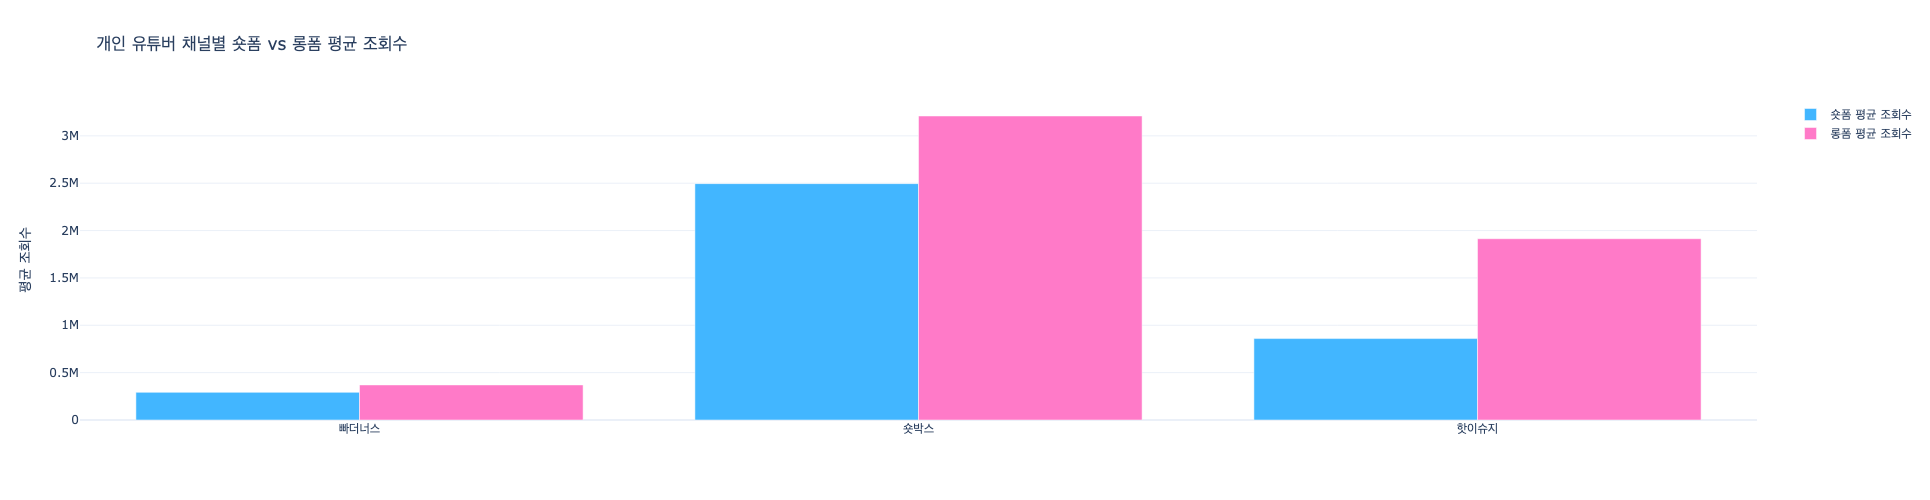

In [13]:
# 채널별 숏폼/롱폼 평균 조회수 비교
view_summary = df.groupby(['channel_name', 'format_type'])['view_count'].mean().reset_index()

shortform_views = view_summary[view_summary['format_type'] == 'shortform'].set_index('channel_name')['view_count']
longform_views  = view_summary[view_summary['format_type'] == 'longform'].set_index('channel_name')['view_count']

channels = list(CHANNELS.keys())

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name='숏폼 평균 조회수',
    x=channels,
    y=shortform_views.reindex(channels).fillna(0),
    marker_color='#42B6FF'
))
fig2.add_trace(go.Bar(
    name='롱폼 평균 조회수',
    x=channels,
    y=longform_views.reindex(channels).fillna(0),
    marker_color='#FF7AC8'
))
fig2.update_layout(
    title='개인 유튜버 채널별 숏폼 vs 롱폼 평균 조회수',
    yaxis_title='평균 조회수',
    barmode='group',
    template='plotly_white',
    height=500
)
fig2.show()